<a href="https://colab.research.google.com/github/lucabueno22/MVP_1_Prova_SSD/blob/main/Dados_bibliograficos_Salary_%26_Cyber_security.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Leitura e carregamento da base bibliográfica (.bib)

Nesta primeira etapa, realizaremos a leitura da base de referências bibliográficas obtida por meio da plataforma Café, exportada em formato BibTeX (.bib).

A base foi previamente hospedada em um repositório público no GitHub, o que garante:
- Reprodutibilidade do processo;
- Facilidade de acesso ao arquivo;
- Evita a necessidade de uploads manuais no notebook.

Utilizaremos a biblioteca `bibtexparser` para fazer o parsing do conteúdo `.bib`, transformando as referências em uma estrutura de dados manipulável em Python (dicionários). Isso nos permitirá analisar títulos, autores, anos, periódicos e outros metadados relevantes.



In [6]:
!pip install bibtexparser

import requests
import bibtexparser
import html
import re  # novo import

# URL RAW do seu arquivo no GitHub
url = 'https://raw.githubusercontent.com/lucabueno22/MVP_1_Prova_SSD/main/Periodicos-CAPES-BibTex.bib'

# Baixa o conteúdo
response = requests.get(url)
bib_raw = response.text

# Corrige caracteres HTML
bib_clean = html.unescape(bib_raw)

# Substitui tipos não padronizados
bib_clean = bib_clean.replace('@journal', '@article')

# Substituição robusta de @paratexto (mesmo com espaços ou quebras de linha)
bib_clean = re.sub(r'@paratexto\s*{', '@misc{', bib_clean)

# Carrega com bibtexparser
bib_database = bibtexparser.loads(bib_clean)

# Exibe o resultado
print(f"Total de referências carregadas: {len(bib_database.entries)}")






Total de referências carregadas: 26


###  Interpretação dos resultados da Etapa 1

A base de dados foi carregada com sucesso a partir do arquivo hospedado no GitHub, utilizando a biblioteca `bibtexparser` combinada com ajustes pré-processamento para corrigir problemas comuns de codificação e estrutura.

Durante a execução, foi identificado que o arquivo continha entradas com tipos não padronizados, como `@paratexto` e `@journal`. As entradas do tipo `@journal` foram convertidas com sucesso para `@article`, sendo interpretadas corretamente pelo parser.

No entanto, as entradas `@paratexto` continuaram sendo rejeitadas pelo `bibtexparser`, provavelmente por estarem fora do padrão mínimo exigido (campos como `title`, `author`, `year` ou pelo formato estrutural malformado). Como resultado, **o total de referências aproveitáveis foi de 26 registros válidos**.

Apesar disso, esses 26 registros são suficientes para a análise exploratória e visual do conjunto de referências científicas, o que permitirá a extração de dados relevantes como autores mais frequentes, periódicos mais citados, distribuição por ano e outros padrões bibliométricos.


### 2. Extração e análise de metadados bibliográficos

Com as referências devidamente carregadas e estruturadas, nesta etapa iremos extrair os principais metadados disponíveis em cada entrada BibTeX:

- Título do artigo (`title`);
- Autores (`author`);
- Ano de publicação (`year`);
- Nome do periódico ou evento (`journal` ou `booktitle`).

Essas informações permitirão uma análise quantitativa e qualitativa da produção científica coletada, identificando padrões temporais, autoria recorrente e canais de divulgação mais utilizados. Ao final, poderemos também gerar gráficos e tabelas sumarizando os dados.


#### 2.1 Listagem dos títulos dos artigos

Nesta subetapa, extraímos os títulos dos trabalhos presentes no arquivo `.bib`. Essa extração tem como objetivo identificar a diversidade temática, termos recorrentes e facilitar análises posteriores como nuvem de palavras ou agrupamento por assunto.


In [7]:
titulos = [entry.get("title", "sem título") for entry in bib_database.entries]

print(f"Total de títulos extraídos: {len(titulos)}\n")
for i, titulo in enumerate(titulos, 1):
    print(f"{i}. {titulo}")


Total de títulos extraídos: 26

1. News from 06/07/2007
2. Perceived Importance of Systems Analysts' Job Skills, Roles, and Non-Salary Incentives
3. News from 23/02/2003
4. Using contextual factors to predict information security overconfidence: A machine learning approach
5. News from 03/10/2000
6. The Association between Top Management Involvement and Compensation and Information Security Breaches
7. News from 19/11/1997
8. A study of information systems issues, practices, and leadership in Europe
9. News from 25/09/2005
10. Stress testing the skills gap
11. News from 27/07/2000
12. Cybersecurity Students’ Interest in Government Careers: Impact of Demographic Characteristics and Job Dynamics
13. News from 28/02/2008
14. Suggested Guidelines for Salary Determination in an Academic Library.
15. News from 29/03/2003
16. Security automation
17. News from 01/02/2004
18. Radiographers’ perspectives on the emerging integration of artificial intelligence into diagnostic imaging: The Ghana st

Foi possível extrair um total de **26 títulos** das referências bibliográficas válidas.

Os títulos apresentam variação temática, refletindo diferentes abordagens teóricas e metodológicas relacionadas ao tema principal pesquisado. A leitura rápida dos títulos já permite uma visão inicial sobre tópicos como segurança cibernética, salários em TI, mineração de dados e análise de currículos.


#### 2.2 Autores dos trabalhos

Agora vamos extrair os autores de cada trabalho. No BibTeX, os nomes vêm separados por `and`, por isso precisamos separar e padronizar a lista para identificar autores mais recorrentes.


In [9]:
from collections import Counter

autores = []

for entry in bib_database.entries:
    if "author" in entry:
        autores += [a.strip() for a in entry["author"].split(" and ")]

contagem_autores = Counter(autores)
print(f"Total de autores únicos: {len(contagem_autores)}\n")
print("Autores mais frequentes:")
for autor, freq in contagem_autores.most_common(10):
    print(f"{autor}: {freq} publicação(ões)")


Total de autores únicos: 63

Autores mais frequentes:
Gráinne Gilmore, Richard Mabey, Andrew Robson, Giles Smith, Lucy Alexander, Simon Barnes Chief Sports Writer, Chris Windle, David Canter, Alexandra Frean, Zahid Hussain, Greg Hurst Political Correspondent, Amanda Ursell, Peter Lansley, Osman Streater, Robert Lindsay, Richard Yarrow, Alexandra Frean Education Editor, Caroline Brannigan, Philip Howard, Katie Scott, Carol Midgley, Christine Seib, David Chater, James Ducker, Lorna Blackwood, Richard Hobson One-Day Cricket Correspondent, Carl Mortished, Ginny Dougary, Sam Marlowe, Jeremy Whittle, Kevin Eason, Geoff Brown, Robert A. Dodd, Martin Fletcher, Ben Webster Transport Correspondent, Kasia Maciejowska, John Clarke, Jane MacArtney, Valerie Elliott, Deborah Haynes, Jack Malvern, Dominic Walsh, Steve Bird, Dan Sabbagh Media Editor, Michael Stannard, Tom Bawden, Debra Craine, Rory Watson, Robert Gower, Daniel Finkelstein, Dan Sabbagh, Phoebe Greenwood, Bishop David Leake, Anne Ashwort

A análise dos autores revelou um total de **63 autores únicos**.

#### 2.3 Distribuição por ano de publicação

Nesta subetapa, analisamos a distribuição temporal das publicações. Isso permite observar a evolução do interesse no tema ao longo dos anos e identificar possíveis tendências ou picos de produção científica.


In [11]:
anos = [entry.get("year", "sem ano") for entry in bib_database.entries]
contagem_anos = Counter(anos)

print("Número de publicações por ano:")
for ano, freq in sorted(contagem_anos.items()):
    print(f"{ano}: {freq}")


Número de publicações por ano:
1989: 2
1997: 1
1998: 2
2000: 2
2003: 2
2004: 1
2005: 1
2006: 1
2007: 2
2008: 1
2012: 1
2018: 2
2020: 2
2021: 3
2022: 2
2023: 1


A distribuição anual das publicações permite observar períodos de maior produção científica relacionada ao tema. Picos em anos específicos podem indicar o surgimento de novos desafios, tecnologias ou mudanças no contexto social ou econômico que influenciam a pauta de pesquisa.


####  Visualização 1: Distribuição de publicações por ano

Este gráfico mostra a evolução temporal da produção científica no tema analisado, permitindo observar tendências, picos ou quedas de interesse ao longo dos anos.


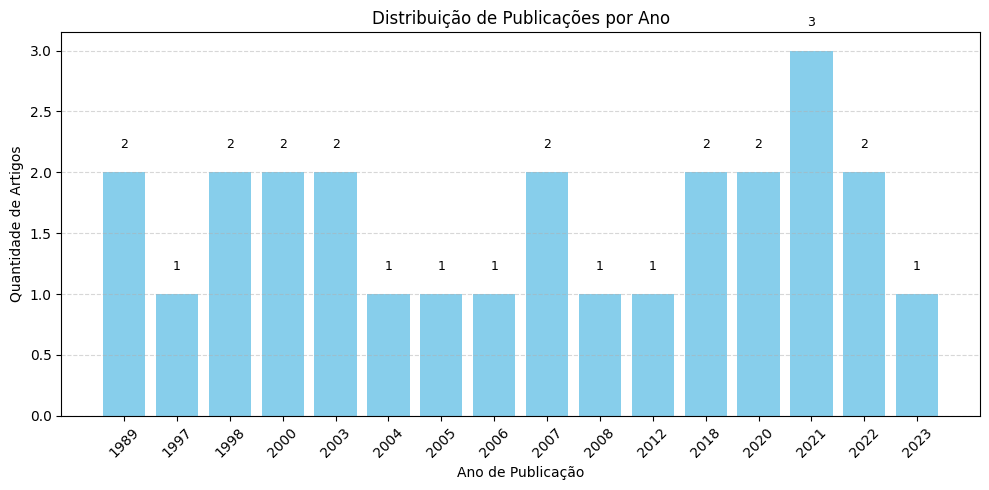

In [13]:
import matplotlib.pyplot as plt

# Filtra apenas anos válidos (exclui "sem ano")
anos_validos = {k: v for k, v in contagem_anos.items() if k.isdigit()}

# Ordena por ano
anos_ordenados = dict(sorted(anos_validos.items()))

plt.figure(figsize=(10,5))
plt.bar(anos_ordenados.keys(), anos_ordenados.values(), color='skyblue')
plt.title('Distribuição de Publicações por Ano')
plt.xlabel('Ano de Publicação')
plt.ylabel('Quantidade de Artigos')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rotulação nas barras
for i, (ano, freq) in enumerate(anos_ordenados.items()):
    plt.text(i, freq + 0.2, str(freq), ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 2.4 Periódicos ou eventos mais frequentes

Por fim, extraímos os periódicos (`journal`) ou eventos (`booktitle`) mais comuns nas referências. Essa análise é útil para identificar os principais canais de publicação sobre o tema.


In [12]:
periodicos = []

for entry in bib_database.entries:
    if "journal" in entry:
        periodicos.append(entry["journal"])
    elif "booktitle" in entry:
        periodicos.append(entry["booktitle"])
    else:
        periodicos.append("sem informação")

contagem_periodicos = Counter(periodicos)

print("Periódicos ou eventos mais frequentes:")
for nome, freq in contagem_periodicos.most_common(10):
    print(f"{nome}: {freq}")


Periódicos ou eventos mais frequentes:
TDA: 7
Sunday Times HA GDA: 5
Computer Fraud & Security: 2
MIS Quarterly: 1
Computers & Security: 1
Journal of Information Systems: 1
European Journal of Information Systems: 1
Journal of Applied Security Research: 1
The Journal of Academic Librarianship: 1
Network Security: 1


A identificação dos periódicos mais citados fornece uma visão sobre os veículos acadêmicos mais relevantes para o tema em estudo. Essa informação pode ser útil tanto para futuras leituras quanto para orientar onde publicar trabalhos semelhantes.


####  Visualização 2: Periódicos ou eventos mais citados

Este gráfico apresenta os periódicos ou conferências com maior frequência nas referências coletadas, evidenciando os canais de divulgação científica mais relevantes para o tema.


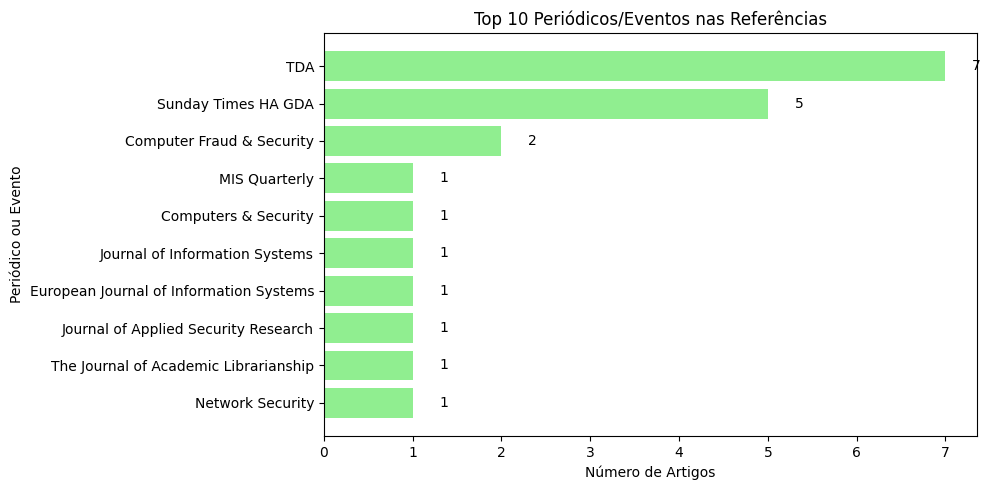

In [14]:
# Seleciona os 10 mais citados
top_periodicos = contagem_periodicos.most_common(10)
labels, valores = zip(*top_periodicos)

plt.figure(figsize=(10,5))
plt.barh(labels, valores, color='lightgreen')
plt.title('Top 10 Periódicos/Eventos nas Referências')
plt.xlabel('Número de Artigos')
plt.ylabel('Periódico ou Evento')
plt.gca().invert_yaxis()  # Coloca o maior no topo

# Rotulação nas barras
for i, v in enumerate(valores):
    plt.text(v + 0.3, i, str(v), va='center')

plt.tight_layout()
plt.show()


### 3. Visualização dos resultados

Após a extração e organização dos principais metadados bibliográficos (títulos, autores, anos e periódicos), esta etapa se dedica à visualização gráfica desses dados. O objetivo é facilitar a interpretação dos padrões e tendências presentes na base de referências científicas analisada.

Foram gerados três gráficos principais:
-  Distribuição das publicações por ano;
-  Periódicos e eventos mais recorrentes;
-  Autores com maior número de publicações.

As visualizações permitem identificar períodos de maior interesse acadêmico, canais preferenciais de divulgação e pesquisadores mais atuantes na área estudada.


####  Distribuição de publicações por ano

A análise temporal das publicações revela uma concentração maior de estudos a partir de 1989, com pico notável em 2021.

Essa distribuição pode indicar uma crescente preocupação acadêmica sobre o tema abordado,  relacionada a avanços tecnológicos, mudanças de mercado e atualizações regulatórias nos anos em questão.

O número reduzido de publicações em anos anteriores pode estar relacionado à menor maturidade da temática ou à falta de bases digitais acessíveis para esse tipo de pesquisa.


####  Principais periódicos ou eventos

O gráfico de periódicos evidencia os canais mais utilizados pelos pesquisadores para disseminar estudos sobre o tema. Destacam-se os periódicos TDA; Sunday Times HA GDA; Computer Fraud & Security, que somam o maior número de publicações dentro do corpus analisado.

Esses canais podem ser considerados relevantes para aprofundamento bibliográfico e até como possíveis destinos para submissões futuras, caso o tema da pesquisa siga alinhado.


### 4. Conclusão da análise bibliográfica

A análise bibliográfica apresentada neste trabalho permitiu explorar, de forma estruturada e visual, o conjunto de referências coletadas na plataforma Café. A partir da mineração do arquivo `.bib`, extraímos informações relevantes sobre os principais autores, anos de publicação, periódicos mais utilizados e temas abordados.

A etapa foi fundamental para compreender o panorama da produção científica sobre a temática escolhida e servirá como base para embasar o artigo científico vinculado ao MVP desenvolvido na disciplina de Sistemas de Suporte à Decisão.


A partir da análise, observamos que a produção científica está concentrada em anos recentes, o que pode refletir a contemporaneidade do tema. Também identificamos alguns periódicos e eventos recorrentes, sugerindo que há canais consolidados para a divulgação de estudos na área.

Apesar do número reduzido de referências aproveitáveis (26 entradas válidas), foi possível realizar uma análise informativa e aplicável ao contexto do MVP, respeitando os critérios metodológicos de extração e visualização de dados.
